In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df = pd.read_csv("../../data/placement.csv")
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [20]:
df.shape

(1000, 3)

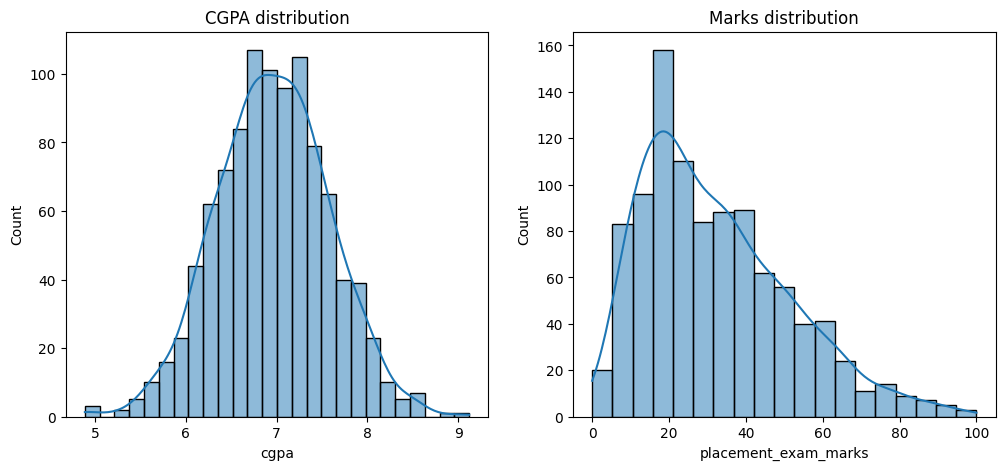

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True)
plt.title("CGPA distribution")

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde = True)
plt.title("Marks distribution")

plt.show()

In [7]:
# CGPA distribution is approximately normal while marks is right skewed

In [10]:
df['placement_exam_marks'].skew() #skewed (as this value not 0)

np.float64(0.8356419499466834)

In [12]:
df['cgpa'].skew() #normal(as its almost 0)

np.float64(-0.014529938929314918)

In [14]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


In [15]:
# mean cg = 6.96, std of cg = 0.6, min cg = 4.89, max cg = 9.12

In [16]:
# Finding the boundaries

df['cgpa'].mean() + 3*df['cgpa'].std() , df['cgpa'].mean() - 3*df['cgpa'].std() 

(np.float64(8.808933625397168), np.float64(5.113546374602832))

In [17]:
# cg outside (5.11 and 8.80) = outliers!

In [19]:
# Printing the outliers --

df[(df['cgpa'] > 8.808) | (df['cgpa'] < 5.113)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [21]:
# Out of 1000 rows, 5 are outliers!

## Trimming (removing the outliers)

### Approach-1

In [23]:
df_trimmed = df[(df['cgpa'] > 5.113) & (df['cgpa'] < 8.808)]
df_trimmed

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


### Approach-2

In [24]:
df['z_score_cgpa'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [25]:
df.head()

,cgpa,placement_exam_marks,placed,z_score_cgpa
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [26]:
df_trimmed_2 = df[(df['z_score_cgpa'] > -3) & (df['z_score_cgpa'] < 3)]
df_trimmed_2

,cgpa,placement_exam_marks,placed,z_score_cgpa
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


## Capping(Assignment boundary values to outliers)

In [27]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [28]:
upper_limit, lower_limit

(np.float64(8.808933625397168), np.float64(5.113546374602832))

In [29]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        df['cgpa'] < lower_limit,
        lower_limit, 
        df['cgpa']
    )
)

In [30]:
df.shape

(1000, 4)

In [31]:
df.describe()

,cgpa,placement_exam_marks,placed,z_score_cgpa
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.225000,0.489000,-1.465494e-16
std,0.612688,19.130822,0.500129,1.000000e+00
min,5.113546,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,8.808934,100.000000,1.000000,3.505062e+00


In [32]:
# done

In [33]:
# :)